In [1]:
import numpy as np
import joblib
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    BatchNormalization,
    Input,
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

### Load clean dataset

In [2]:
data = np.load("../artifacts/dataset_sequences.npz")

X_train = data["X_train"]
y_train = data["y_train"]

X_val = data["X_val"]
y_val = data["y_val"]

X_test = data["X_test"]
y_test = data["y_test"]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(216981, 24, 32)
(43963, 24, 32)
(28428, 24, 32)


### Load Metadata

In [3]:
metadata = joblib.load("../artifacts/dataset_metadata.pkl")

WINDOW_SIZE = metadata["window_size"]
feature_cols = metadata["feature_cols"]
target_col = metadata["target_col"]

print(metadata)

{'window_size': 24, 'feature_cols': ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'CO', 'SO2', 'O3', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_weekend', 'PM2.5_roll3', 'PM2.5_roll6', 'PM2.5_roll24', 'PM10_roll3', 'PM10_roll6', 'PM10_roll24', 'NO2_roll3', 'NO2_roll6', 'NO2_roll24', 'CO_roll3', 'CO_roll6', 'CO_roll24', 'O3_roll3', 'O3_roll6', 'O3_roll24', 'PM2.5_lag1', 'AQI_lag1', 'PM2.5_lag3', 'AQI_lag3'], 'target_col': 'AQI', 'n_features': 32, 'input_shape': (24, 32)}


### Load Scaler

In [4]:
scaler_X = joblib.load("../artifacts/scaler_X.pkl")
scaler_y = joblib.load("../artifacts/scaler_y.pkl")

### LSTM Arsitektur

In [5]:
model = Sequential([

    Input(shape=(X_train.shape[1], X_train.shape[2])),

    # LSTM Layer 1
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    BatchNormalization(),

    # LSTM Layer 2
    LSTM(64),
    Dropout(0.2),
    BatchNormalization(),

    # Dense Head
    Dense(32, activation="relu"),
    Dropout(0.1),

    Dense(1)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,721 (526.25 KB)

 Trainable params: 134,337 (524.75 KB)

 Non-trainable params: 384 (1.50 KB)

In [6]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

In [7]:
callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        filepath="../models/best_lstm.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )

]

In [8]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1

)

Epoch 1/50
3389/3391 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0425 - mae: 0.1130
Epoch 1: val_loss improved from None to 0.00034, saving model to ../models/best_lstm.keras
3391/3391 ━━━━━━━━━━━━━━━━━━━━ 92s 26ms/step - loss: 0.0115 - mae: 0.0529 - val_loss: 3.3645e-04 - val_mae: 0.0138 - learning_rate: 0.0010
Epoch 2/50
3389/3391 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 8.3552e-04 - mae: 0.0198
Epoch 2: val_loss did not improve from 0.00034
3391/3391 ━━━━━━━━━━━━━━━━━━━━ 104s 31ms/step - loss: 7.3720e-04 - mae: 0.0185 - val_loss: 7.1654e-04 - val_mae: 0.0175 - learning_rate: 0.0010
Epoch 3/50
3390/3391 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 5.5202e-04 - mae: 0.0159
Epoch 3: val_loss improved from 0.00034 to 0.00014, saving model to ../models/best_lstm.keras
3391/3391 ━━━━━━━━━━━━━━━━━━━━ 106s 31ms/step - loss: 5.0440e-04 - mae: 0.0152 - val_loss: 1.4239e-04 - val_mae: 0.0087 - learning_rate: 0.0010
Epoch 4/50
3389/3391 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 4.1983e-04 - mae: 

In [9]:
joblib.dump(
    history.history,
    "../models/lstm_history.pkl"
)

print("Training history berhasil disimpan.")

Training history berhasil disimpan.


In [10]:
best_model = load_model("../models/best_lstm.keras")
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 403,397 (1.54 MB)

 Trainable params: 134,337 (524.75 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 268,676 (1.02 MB)

In [11]:
# Prediksi
y_train_pred = best_model.predict(X_train, verbose=0)
y_val_pred   = best_model.predict(X_val, verbose=0)
y_test_pred  = best_model.predict(X_test, verbose=0)

In [12]:
# Inverse transform ke skala AQI asli
y_train_true = scaler_y.inverse_transform(y_train.reshape(-1, 1))
y_val_true   = scaler_y.inverse_transform(y_val.reshape(-1, 1))
y_test_true  = scaler_y.inverse_transform(y_test.reshape(-1, 1))

y_train_pred = scaler_y.inverse_transform(y_train_pred)
y_val_pred   = scaler_y.inverse_transform(y_val_pred)
y_test_pred  = scaler_y.inverse_transform(y_test_pred)

In [13]:
def evaluate_regression(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

    nrmse = rmse / (np.max(y_true) - np.min(y_true))

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "NRMSE": nrmse,
        "R²": r2
    }

In [14]:
train_metrics = evaluate_regression(
    y_train_true,
    y_train_pred
)

val_metrics = evaluate_regression(
    y_val_true,
    y_val_pred
)

test_metrics = evaluate_regression(
    y_test_true,
    y_test_pred
)

In [15]:
results = pd.DataFrame(
    [
        train_metrics,
        val_metrics,
        test_metrics
    ],
    index=[
        "Train",
        "Validation",
        "Test"
    ]
)

results

,MAE,MSE,RMSE,NRMSE,R²
Train,3.030088,43.634076,6.605609,0.006333,0.994126
Validation,2.625533,31.715451,5.631647,0.008546,0.994373
Test,2.434366,23.933997,4.892238,0.008349,0.987785


In [16]:
results.to_csv(
    "../models/lstm_evaluation.csv",
    index=True
)

print("Hasil evaluasi berhasil disimpan.")

Hasil evaluasi berhasil disimpan.


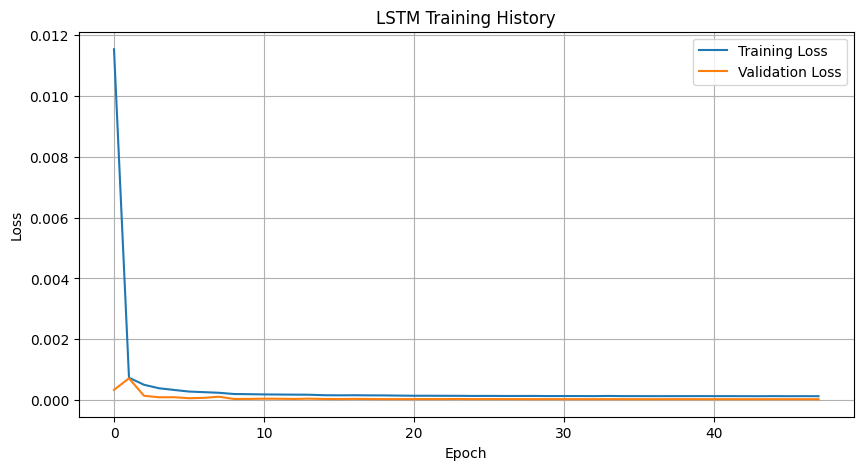

In [17]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training History")

plt.legend()

plt.grid(True)

plt.show()

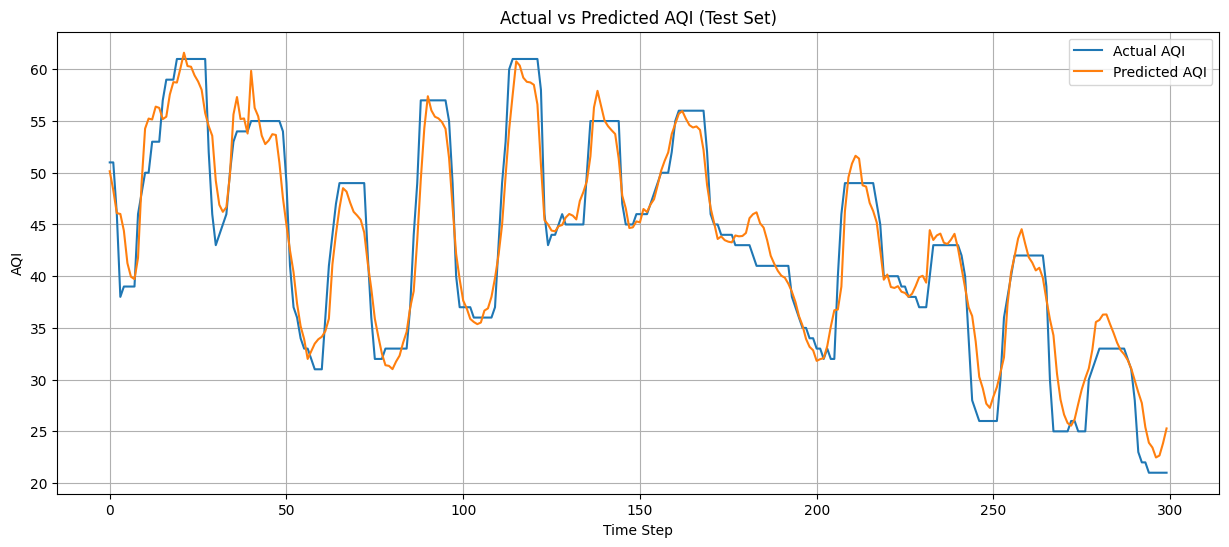

In [18]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test_true[:300],
    label="Actual AQI"
)

plt.plot(
    y_test_pred[:300],
    label="Predicted AQI"
)

plt.title("Actual vs Predicted AQI (Test Set)")
plt.xlabel("Time Step")
plt.ylabel("AQI")

plt.legend()

plt.grid(True)

plt.show() 

## Residual Train

In [19]:
residual_train = (y_train_true - y_train_pred).ravel()
residual_val   = (y_val_true - y_val_pred).ravel()
residual_test  = (y_test_true - y_test_pred).ravel()

In [20]:
np.savez_compressed(

    "../artifacts/lstm_predictions.npz",
    y_train_true=y_train_true,
    y_train_pred=y_train_pred,

    y_val_true=y_val_true,
    y_val_pred=y_val_pred,

    y_test_true=y_test_true,
    y_test_pred=y_test_pred,

    residual_train=residual_train,
    residual_val=residual_val,
    residual_test=residual_test

)

In [21]:
config = {

    "epochs":100,

    "batch_size":64,

    "optimizer":"Adam",

    "learning_rate":0.001,

    "window_size":24,

    "features":feature_cols

}

joblib.dump(
    config,
    "../models/lstm_config.pkl"
)

['../models/lstm_config.pkl']